                           Unobserved Components Results                            
Dep. Variable:                      demanda   No. Observations:                  731
Model:                   local linear trend   Log Likelihood               -2726.916
                   + stochastic seasonal(7)   AIC                           5463.833
                                    + cycle   BIC                           5486.736
Date:                      Mon, 13 Jul 2026   HQIC                          5472.674
Time:                              13:50:11                                         
Sample:                          01-01-2024                                         
                               - 12-31-2025                                         
Covariance Type:                        opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

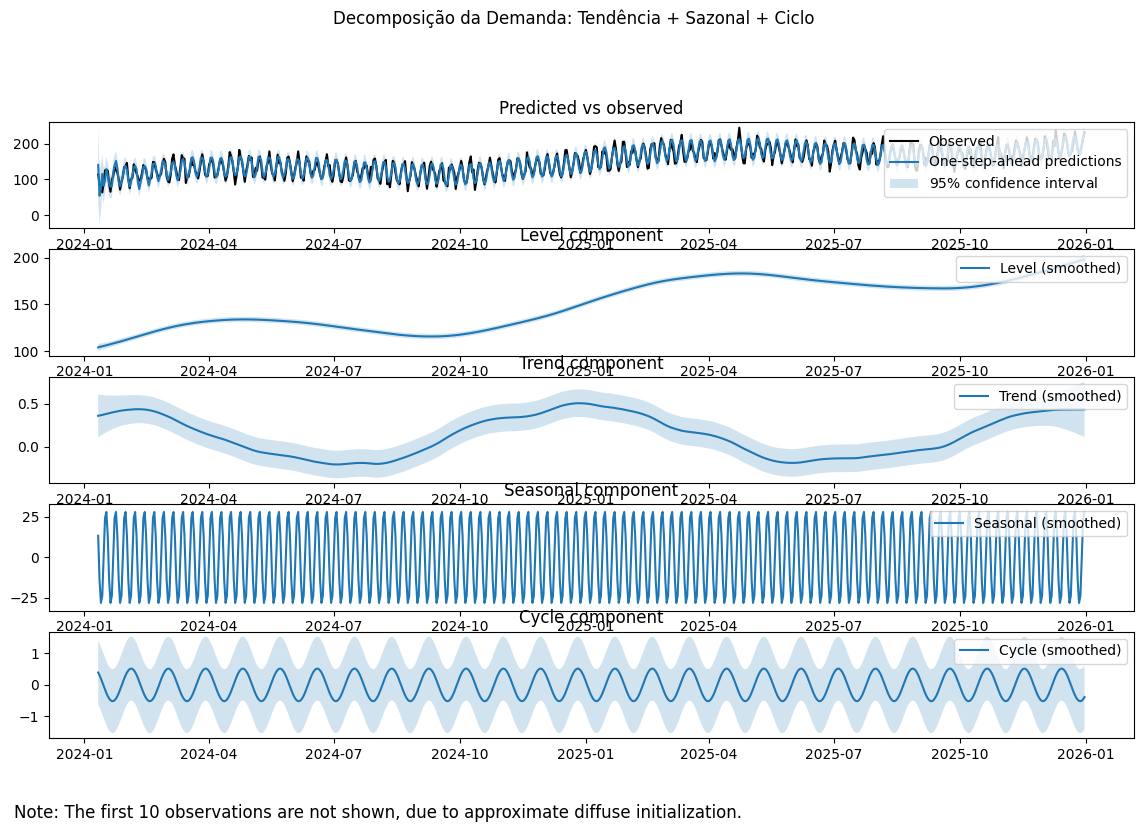

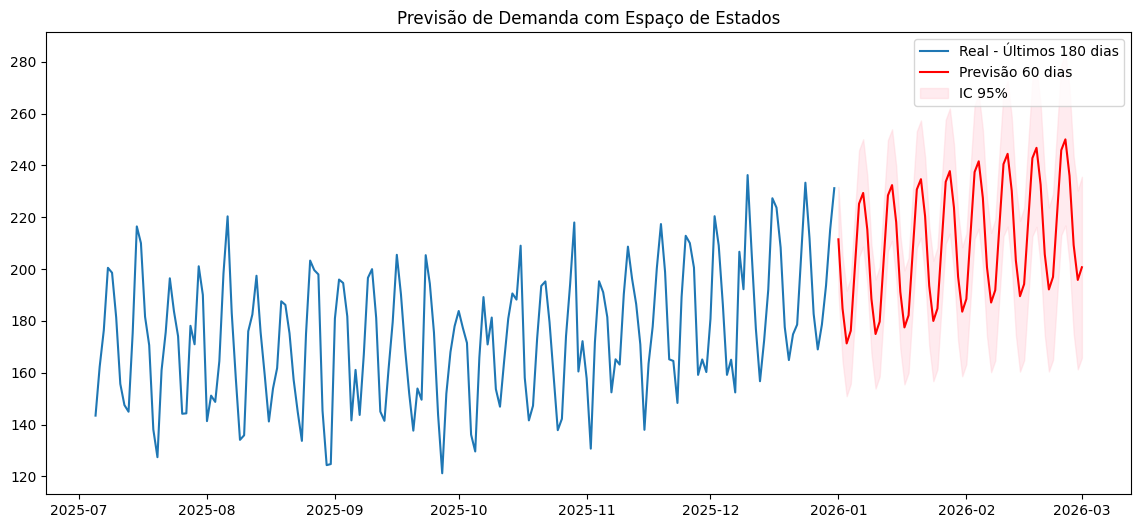

Demanda prevista para os próximos 7 dias: 199.9 unidades/dia


In [4]:

import sys
import subprocess

# Lista de pacotes para instalar
pacotes = ['statsmodels ', 'matplotlib']

# O parâmetro "-q" (ou "--quiet") reduz a saída do log no console
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pacotes)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. CRIAR DADOS FALSOS DE DEMANDA: 2 anos diários
np.random.seed(42)
dias = pd.date_range('2024-01-01', '2025-12-31', freq='D')
n = len(dias)

tendencia = np.linspace(100, 200, n) # cresce 100 vendas em 2 anos
sazonal_semana = 30 * np.sin(np.arange(n) * 2 * np.pi / 7) # pico no fds
sazonal_ano = 20 * np.sin(np.arange(n) * 2 * np.pi / 365) # vende mais no inverno
ruido = np.random.normal(0, 10, n)

demanda = tendencia + sazonal_semana + sazonal_ano + ruido
df = pd.DataFrame({'demanda': demanda}, index=dias)

# 2. TREINAR MODELO ESPAÇO DE ESTADOS
# level='local linear trend' = tendência que pode subir/descer
# seasonal=7 = sazonalidade semanal. seasonal=365 = anual
mod = sm.tsa.UnobservedComponents(
    df['demanda'],
    level='local linear trend',
    seasonal=7, # semanal
    cycle=True # ciclo anual
)
res = mod.fit(disp=False)
print(res.summary())

# 3. DECOMPOR: ver o que é tendência, o que é sazonal
fig = res.plot_components(figsize=(14, 8))
plt.suptitle('Decomposição da Demanda: Tendência + Sazonal + Ciclo', y=1.02)
plt.show()

# 4. PREVER PRÓXIMOS 60 DIAS
forecast = res.get_forecast(steps=60)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# 5. PLOTAR FORECAST
plt.figure(figsize=(14,6))
plt.plot(df['demanda'][-180:], label='Real - Últimos 180 dias')
plt.plot(forecast_mean, color='r', label='Previsão 60 dias')
plt.fill_between(forecast_ci.index, 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1], 
                 color='pink', alpha=0.3, label='IC 95%')
plt.title('Previsão de Demanda com Espaço de Estados')
plt.legend()
plt.show()

print(f"Demanda prevista para os próximos 7 dias: {forecast_mean[:7].mean():.1f} unidades/dia")